# # 1. Import Libraries and Load Dataset

In [1]:
import os
import random
from pathlib import Path
import cv2
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Set global plot style
plt.style.use('seaborn-v0_8-whitegrid')

# # 2. Dataset Download & Metadata Extraction


In [2]:
# Download dataset via kagglehub
print("Downloading dataset...")
download_path = kagglehub.dataset_download("iarunava/cell-images-for-detecting-malaria")
base_path = Path(download_path)

# Resolve target directory path
if (base_path / "cell_images").exists():
    data_dir = base_path / "cell_images"
    if (data_dir / "cell_images").exists():
        data_dir = data_dir / "cell_images"
else:
    data_dir = base_path

print(f"Data directory: {data_dir}")

# Extract metadata from image directory
records = []
categories = ['Parasitized', 'Uninfected']

for category in categories:
    folder = data_dir / category
    for img_path in folder.glob('*.png'):
        img = cv2.imread(str(img_path))
        if img is None:
            continue
            
        h, w, _ = img.shape
        records.append({
            'filename': img_path.name,
            'path': str(img_path),
            'category': category,
            'height': h,
            'width': w,
            'aspect_ratio': w / float(h),
            'total_pixels': h * w
        })

df = pd.DataFrame(records)
print(f"Total dataset shape: {df.shape}")
df.head()

100%|██████████| 675M/675M [00:34<00:00, 20.6MB/s] 

Extracting files...


Data directory: /Users/andersvestergaard/.cache/kagglehub/datasets/iarunava/cell-images-for-detecting-malaria/versions/1/cell_images/cell_images
Total dataset shape: (27558, 7)


,filename,path,category,height,width,aspect_ratio,total_pixels
0,C118P79ThinF_IMG_20151002_105018_cell_150.png,/Users/andersvestergaard/.cache/kagglehub/data...,Parasitized,115,112,0.973913,12880
1,C189P150ThinF_IMG_20151203_142224_cell_84.png,/Users/andersvestergaard/.cache/kagglehub/data...,Parasitized,121,118,0.975207,14278
2,C91P52ThinF_IMG_20150821_123116_cell_189.png,/Users/andersvestergaard/.cache/kagglehub/data...,Parasitized,169,148,0.875740,25012
3,C84P45ThinF_IMG_20150818_101226_cell_98.png,/Users/andersvestergaard/.cache/kagglehub/data...,Parasitized,106,136,1.283019,14416
4,C144P105ThinF_IMG_20151015_163432_cell_310.png,/Users/andersvestergaard/.cache/kagglehub/data...,Parasitized,91,103,1.131868,9373


# # 3. Class Distribution Analysis


/var/folders/td/ktsl8nl13w76c0_3jq93kp7c0000gn/T/ipykernel_33801/2998342719.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=palette)


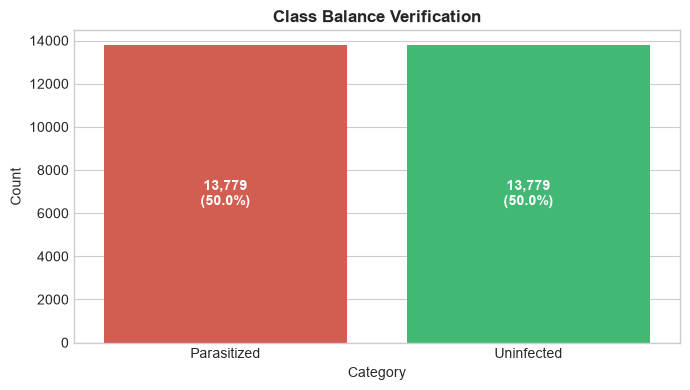


Class distribution:
category
Parasitized    13779
Uninfected     13779
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(7, 4))
palette = {'Parasitized': '#e74c3c', 'Uninfected': '#2ecc71'}

counts = df['category'].value_counts()
sns.barplot(x=counts.index, y=counts.values, palette=palette)

plt.title("Class Balance Verification", fontsize=12, fontweight='bold')
plt.xlabel("Category")
plt.ylabel("Count")

for i, count in enumerate(counts.values):
    pct = (count / len(df)) * 100
    plt.text(i, count / 2, f"{count:,}\n({pct:.1f}%)", ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nClass distribution:")
print(counts)

# # 4. Qualitative Image Inspection

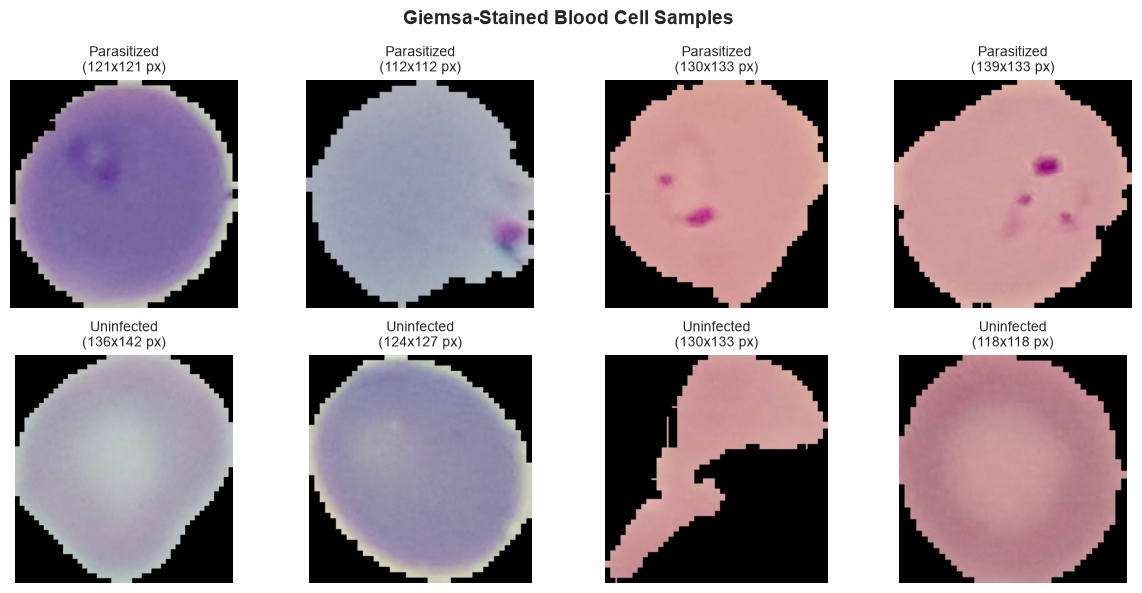

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for row_idx, category in enumerate(categories):
    samples = df[df['category'] == category]['path'].sample(4, random_state=SEED).tolist()
    
    for col_idx, img_path in enumerate(samples):
        ax = axes[row_idx, col_idx]
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        
        ax.imshow(img)
        h, w, _ = img.shape
        ax.set_title(f"{category}\n({w}x{h} px)", fontsize=10)
        ax.axis('off')

plt.suptitle("Giemsa-Stained Blood Cell Samples", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# # 5. Image Dimension & Aspect Ratio Analysis

/var/folders/td/ktsl8nl13w76c0_3jq93kp7c0000gn/T/ipykernel_33801/1742558318.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


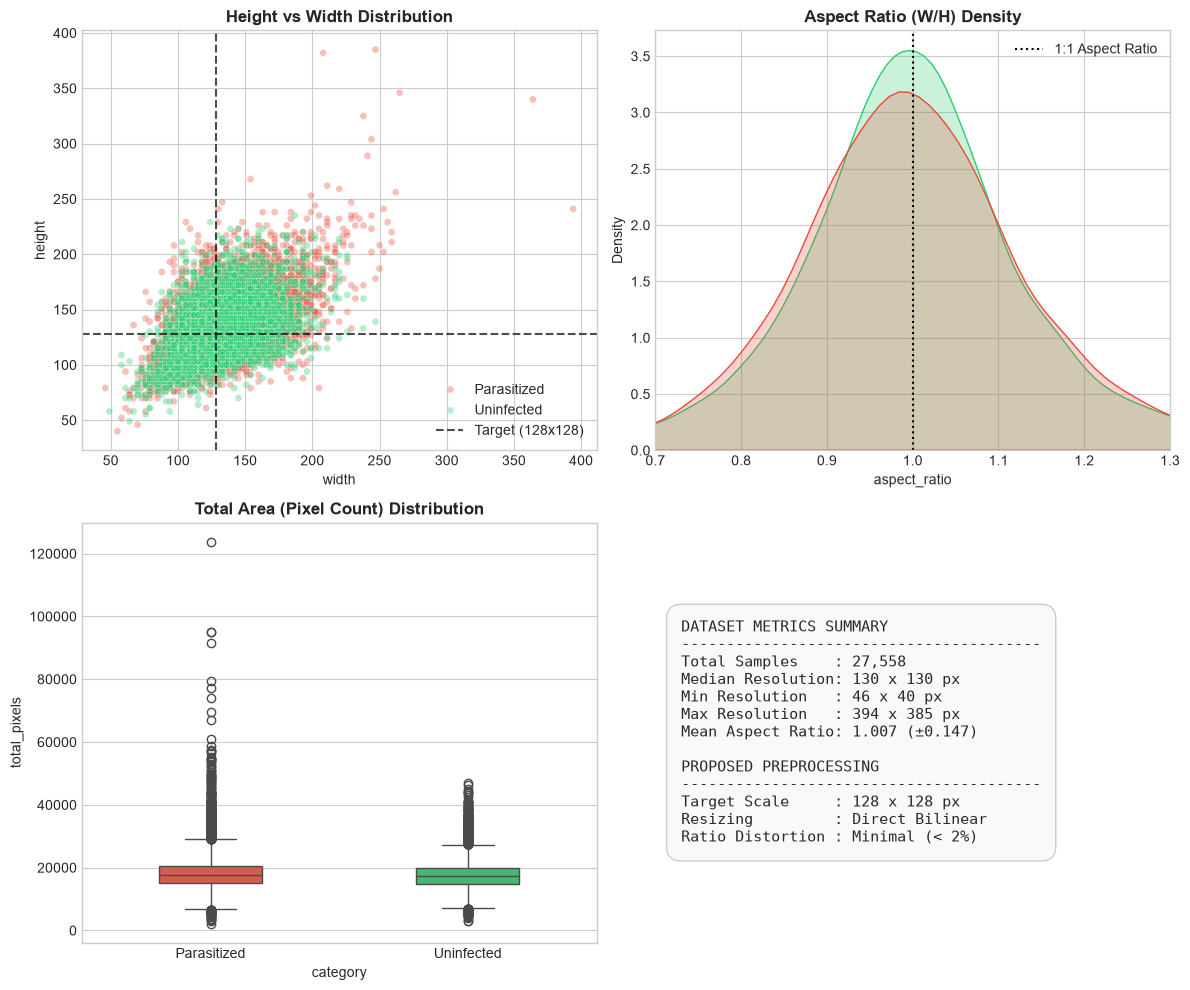

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Height vs Width Scatter Plot
sns.scatterplot(
    data=df, x='width', y='height', hue='category',
    alpha=0.35, palette=palette, ax=axes[0, 0], s=25
)
axes[0, 0].set_title("Height vs Width Distribution", fontsize=12, fontweight='bold')
axes[0, 0].axvline(128, color='black', linestyle='--', alpha=0.7, label='Target (128x128)')
axes[0, 0].axhline(128, color='black', linestyle='--', alpha=0.7)
axes[0, 0].legend()

# Aspect Ratio KDE Plot
sns.kdeplot(
    data=df, x='aspect_ratio', hue='category', fill=True,
    palette=palette, ax=axes[0, 1], common_norm=False
)
axes[0, 1].set_title("Aspect Ratio (W/H) Density", fontsize=12, fontweight='bold')
axes[0, 1].axvline(1.0, color='black', linestyle=':', label='1:1 Aspect Ratio')
axes[0, 1].set_xlim(0.7, 1.3)
axes[0, 1].legend()

# Total Pixel Count Boxplot
sns.boxplot(
    data=df, x='category', y='total_pixels',
    palette=palette, ax=axes[1, 0], width=0.4
)
axes[1, 0].set_title("Total Area (Pixel Count) Distribution", fontsize=12, fontweight='bold')

# Summary Statistics Block
axes[1, 1].axis('off')
summary_text = (
    f"DATASET METRICS SUMMARY\n"
    f"----------------------------------------\n"
    f"Total Samples    : {len(df):,}\n"
    f"Median Resolution: {int(df['width'].median())} x {int(df['height'].median())} px\n"
    f"Min Resolution   : {df['width'].min()} x {df['height'].min()} px\n"
    f"Max Resolution   : {df['width'].max()} x {df['height'].max()} px\n"
    f"Mean Aspect Ratio: {df['aspect_ratio'].mean():.3f} (±{df['aspect_ratio'].std():.3f})\n\n"
    f"PROPOSED PREPROCESSING\n"
    f"----------------------------------------\n"
    f"Target Scale     : 128 x 128 px\n"
    f"Resizing         : Direct Bilinear\n"
    f"Ratio Distortion : Minimal (< 2%)"
)

axes[1, 1].text(
    0.05, 0.5, summary_text, fontsize=10.5, family='monospace',
    verticalalignment='center', bbox=dict(boxstyle='round,pad=1', facecolor='#f8f9fa', edgecolor='#cccccc')
)

plt.tight_layout()
plt.show()